In [ ]:
# Imports
import os

# Set the JAX_PLATFORMS environment variable to "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.animation as animation
import numpy as np

import jax
import matplotlib.pyplot as plt
from kandel.utility.visualization import (
    add_mse_network_plasticity,
    add_random_neural_time_series,
    add_network_2d_pca,
    add_step_rewards,
    add_self_similarity_heatmap,
    add_histogram_hebbian_parameters,
)
from gymnasium.wrappers import RecordVideo
from kandel.sim_api.gymnasium import evaluate
from kandel.utility.checkpoint_loader import load_environment, load_policy

In [8]:
path = "/home/alexanderdittrich/Downloads/ocarina/250418093513-halfcheetah-mlp-hebbian-adaptive-es-4/"
path = "/home/alexanderdittrich/Downloads/ocarina/250420010645-halfcheetah-mlp-adaptive-es-10"
checkpoint = 999
policy_id = 0
seed = 4
episode_length = 1000
viewer_resolution = (640, 480)

## Rendering scene

In [9]:
env, info = load_environment(
    checkpoint_directory=path,
    checkpoint=checkpoint,
    render_mode="rgb_array",
    width=viewer_resolution[0],
    height=viewer_resolution[1],
    episode_length=episode_length,
)

env = RecordVideo(
    env,
    video_folder="/home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots/",
    name_prefix="run_static",
    episode_trigger=lambda x: True,
)

policy, policy_params = load_policy(
    checkpoint_directory=path,
    checkpoint=checkpoint,
    policy_id=policy_id,
)

forward_fcn = jax.jit(policy.forward)
update_fcn = jax.jit(policy.update)
reset_fcn = policy.reset

rng = jax.random.key(seed)
rng_reset, rng_eval = jax.random.split(rng)

policy_params = reset_fcn(policy_params, rng_reset)

reward, length, _ = evaluate(
    random_key=rng_eval,
    envs=env,
    forward_fcn=forward_fcn,
    update_fcn=update_fcn,
    policy_params=policy_params,
    episode_steps=episode_length,
    environment_interval=info["step_interval"],
    hebbian_update_interval=info["update_interval"],
    ignore_terminations=True,
)

env.close()

print(f"Reward: {reward}")

/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init


Reward: [4618.298]


## Weight analysis


In [ ]:
def generate_plot(path, checkpoint, policy_id, seed, episode_length):
    fig, axs = plt.subplots(1, 6, figsize=(14.0, 2.0))

    add_step_rewards(
        ax=axs[0],
        checkpoint_directory=path,
        checkpoint=checkpoint,
        policy_id=policy_id,
        episode_length=episode_length,
        seed=seed,
        eval_fcn=evaluate,
        env_kwargs={},
        color="#B51F1F",
    )

    add_random_neural_time_series(
        ax=axs[1],
        checkpoint_directory=path,
        checkpoint=checkpoint,
        policy_id=policy_id,
        num_neurons=10,
        episode_length=episode_length,
        seed=seed,
        eval_fcn=evaluate,
        env_kwargs={},
        add_legend=False,
    )

    add_mse_network_plasticity(
        ax=axs[2],
        checkpoint_directory=path,
        checkpoint=checkpoint,
        policy_id=policy_id,
        episode_length=episode_length,
        seed=seed,
        eval_fcn=evaluate,
        marker=".",
        alpha=0.6,
        color="#413D3A",
    )

    add_self_similarity_heatmap(
        ax=axs[3],
        checkpoint_directory=path,
        checkpoint=checkpoint,
        policy_id=policy_id,
        seed=seed,
        cmap="viridis",
        episode_length=episode_length,
        eval_fcn=evaluate,
        colorbar_range=[0.0, 10.0],
    )

    add_network_2d_pca(
        ax=axs[4],
        checkpoint_directory=path,
        checkpoint=checkpoint,
        policy_id=policy_id,
        seed=seed,
        eval_fcn=evaluate,
        episode_length=episode_length,
        color="grey",
        alpha=0.6,
    )

    add_histogram_hebbian_parameters(
        ax=axs[5],
        checkpoint_directory=path,
        checkpoint=checkpoint,
        policy_id=policy_id,
    )

    for ax in axs[:3]:
        # ax.set_xlim((0, 12.0))
        ax.set_xlabel("Time (s)")

    ylabels = ["Reward (-)", "Synaptic weight (-)", "Accumulated Change (-)"]

    for ax, label in zip(axs, ylabels):
        ax.set_ylabel(label)

    titles = [
        "Life-time rewards",
        "Synaptic activity",
        "Network plasticity",
        "Self-Similarity",
        "PCA",
        "Hebbian Coefficients",
    ]
    for i, ax in enumerate(axs):
        ax.set_title(titles[i])

    fig.tight_layout()

    return fig, axs


fig, axs = generate_plot(
    path=path,
    checkpoint=checkpoint,
    policy_id=policy_id,
    seed=seed,
    episode_length=episode_length,
)

Weight evolution animation saved as weight_evolution.gif
Animation shows 1001 time steps
Weight range: [-9.256, 8.564]


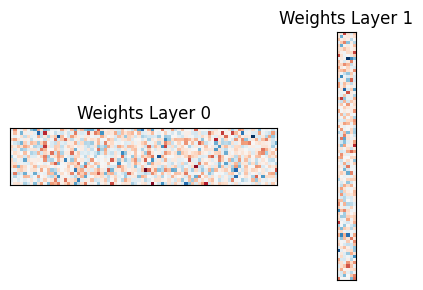

In [ ]:
def create_weight_animation():
    # Load environment and policy
    env, info = load_environment(
        checkpoint_directory=path,
        checkpoint=checkpoint,
        render_mode=None,  # No rendering needed for weight analysis
    )

    policy, policy_params = load_policy(
        checkpoint_directory=path,
        checkpoint=checkpoint,
        policy_id=policy_id,
    )

    forward_fcn = jax.jit(policy.forward)
    update_fcn = jax.jit(policy.update)
    reset_fcn = policy.reset

    rng = jax.random.key(seed)
    rng_reset, rng_eval = jax.random.split(rng)

    policy_params = reset_fcn(policy_params, rng_reset)

    # Run evaluation and collect weight history
    reward, length, _, network_hist = evaluate(
        random_key=rng_eval,
        envs=env,
        forward_fcn=forward_fcn,
        update_fcn=update_fcn,
        policy_params=policy_params,
        episode_steps=episode_length,
        environment_interval=info["step_interval"],
        hebbian_update_interval=info["update_interval"],
        record_policy=True,
    )

    env.close()

    # Extract weight matrices from history
    layers = list(network_hist[0]["kernel_params"].keys())
    weight_history = []

    for t in range(len(network_hist)):
        weights_at_t = []
        for layer in layers:
            W = network_hist[t]["kernel_params"][layer]["W"]
            weights_at_t.append(W)
        weight_history.append(weights_at_t)

    # Find global min/max for consistent color scale
    all_weights = []
    for t in range(len(weight_history)):
        for layer_weights in weight_history[t]:
            all_weights.extend(layer_weights.flatten())

    vmin = np.min(all_weights)
    vmax = np.max(all_weights)

    # Create figure and subplots
    num_layers = len(layers)
    fig, axes = plt.subplots(1, num_layers, figsize=(5, 3))
    if num_layers == 1:
        axes = [axes]

    # Initialize heatmaps
    images = []
    for i, (ax, layer) in enumerate(zip(axes, layers)):
        im = ax.imshow(
            weight_history[0][i],
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            aspect="equal",
        )
        ax.set_title(f"Weights Layer {i}")
        # ax.set_xlabel('Output Neurons')
        # ax.set_ylabel('Input Neurons')
        ax.set_yticks([])
        ax.set_xticks([])

        images.append(im)

    # Add colorbar
    # cbar = plt.colorbar(images[0], ax=axes, fraction=0.046, pad=0.04)
    # cbar.set_label('Weight Value', rotation=270, labelpad=15)

    # Animation function
    def animate(frame):
        if frame < len(weight_history):
            for i, im in enumerate(images):
                im.set_array(weight_history[frame][i])
        return images

    # Create and save animation
    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=len(weight_history),
        interval=100,
        blit=False,
        repeat=True,
    )

    # Save animation
    anim.save("plots/weight_evolution.gif", writer="pillow", fps=10, dpi=200)
    print(f"Weight evolution animation saved as weight_evolution.gif")
    print(f"Animation shows {len(weight_history)} time steps")
    print(f"Weight range: [{vmin:.3f}, {vmax:.3f}]")

    plt.tight_layout()
    plt.show()

    return anim


# Create the animation
weight_anim = create_weight_animation()